# 第 5 节课 · Transformer 基础

## 本 Notebook 目标

这节课你已经看过 3Blue1Brown 的 Attention 视频和 Transformer 论文精读，所以这里不再从头推导原理，只快速回顾结论。

重点是**动手搭三个完整小模型**：
1. **Mini Transformer Encoder**：从零写 Scaled Dot-Product Attention、Multi-Head、FFN、残差、LayerNorm。
2. **Mini BERT**：Encoder-only + MLM（Masked Language Modeling），看它能不能学会 `not [MASK] → good`。
3. **Mini GPT**：Decoder-only + Next Token Prediction，用因果 mask 做文本续写。
4. 最后对比真实 **`bert-base-uncased`** 与 **`gpt2`** 的 attention 模式。

本节包含两部分：① 从零实现 Mini Transformer/BERT/GPT，理解原理；② 加载 `bert-base-chinese` 和 `uer/gpt2-chinese-cluecorpussmall` 做真实 fine-tune。**第二部分是推荐做法**，因为 37 万字符唐诗数据量太小，从零训练效果差。

## 0. 环境准备

需要安装：`pip install torch transformers numpy matplotlib`

下面导入库并检查设备。


In [89]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch 版本: {torch.__version__}")
print(f"使用设备: {device}")

# 固定随机种子
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


PyTorch 版本: 2.12.1+cu130
使用设备: cuda


## 1. 快速回顾（只写结论）

你已经学过原理，这里只列要点。


### Self-Attention 公式

对于序列中第 $i$ 个位置：

$$y_i = \sum_j \text{softmax}\left(\frac{Q_i K_j^T}{\sqrt{d_k}}\right) V_j$$

- $Q, K, V$ 由输入分别线性投影得到。
- $\sqrt{d_k}$ 是缩放因子，防止点积过大导致 softmax 梯度消失。


### Multi-Head、位置编码与三种架构

| 概念 | 结论 |
|---|---|
| **Multi-Head Attention** | 并行跑 $h$ 次 attention，结果拼接再投影，每个 head 可关注不同关系。 |
| **Positional Encoding** | Transformer 本身无位置信息，需显式加入位置编码（正弦/可学习）。 |
| **BERT** | Encoder-only，双向 attention，适合理解任务。 |
| **GPT-2** | Decoder-only，因果/单向 attention，适合生成任务。 |
| **T5** | Encoder-Decoder，Encoder 双向、Decoder 单向并带 Cross Attention。 |


## 2. 动手搭建 1：Mini Transformer Encoder

从零写一个完整的 Transformer Encoder：Embedding + 位置编码 + N 个 Encoder Block + 输出投影。


In [90]:
class MultiHeadAttention(nn.Module):
    """多头自注意力：Q/K/V 投影 → 分头 → scaling → softmax → 拼接 → 输出投影。"""
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model 必须能被 num_heads 整除"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        seq_len = query.size(1)

        # 线性投影并分头: (batch, seq, d_model) -> (batch, heads, seq, d_k)
        Q = self.W_q(query).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

        # Scaled Dot-Product Attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn_weights = F.softmax(scores, dim=-1)
        out = torch.matmul(attn_weights, V)

        # 拼接多头并输出投影
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        out = self.W_o(out)
        return out, attn_weights


In [91]:
class TransformerEncoderBlock(nn.Module):
    """Self-Attention + FFN + 残差 + LayerNorm。"""
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_out, attn = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x, attn


In [92]:
class PositionalEncoding(nn.Module):
    """正弦/余弦位置编码。"""
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) *
            (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


In [93]:
class TransformerEncoder(nn.Module):
    """完整 Transformer Encoder：Embedding + Positional Encoding + N 个 Block + 输出投影。"""
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, max_len=512, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.output_projection = nn.Linear(d_model, vocab_size)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x, mask=None):
        x = self.embedding(x) * np.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        all_attns = []
        for layer in self.layers:
            x, attn = layer(x, mask)
            all_attns.append(attn)
        logits = self.output_projection(x)
        return logits, all_attns


# 测试 forward
vocab_size_test = 20
d_model = 32
num_heads = 4
d_ff = d_model * 4
num_layers = 2

encoder_test = TransformerEncoder(vocab_size_test, d_model, num_heads, d_ff, num_layers)
x_test = torch.randint(0, vocab_size_test, (2, 10))
logits_test, attns_test = encoder_test(x_test)
print(f"输入 shape: {x_test.shape}")
print(f"输出 logits shape: {logits_test.shape}")
print(f"注意力层数: {len(attns_test)}, 每层 shape: {attns_test[0].shape}")
print(f"模型参数量: {sum(p.numel() for p in encoder_test.parameters()):,}")


输入 shape: torch.Size([2, 10])
输出 logits shape: torch.Size([2, 10, 20])
注意力层数: 2, 每层 shape: torch.Size([2, 4, 10, 10])
模型参数量: 26,708


## 3. 动手搭建 2：Mini BERT（Encoder-only + MLM）

把上面的 Encoder 改造成 BERT 风格：加 `[CLS]`、`[MASK]`、`[PAD]`，用 MLM 目标训练。

目标：看模型能否学会 `not [MASK] → good`、`acting [MASK] → great`。


In [94]:
# 加载唐诗数据库，用字符级 tokenization
import random

random.seed(SEED)

TANG_PATH = "D:/深度学习培训/课程/第五节课/tanshi.txt"
with open(TANG_PATH, "r", encoding="utf-8") as f:
    all_lines = [line.strip() for line in f if line.strip()]

# 使用全部 3 万句训练，让模型见过足够多的唐诗模式
# 如果课堂时间紧，可以把 random.sample(all_lines, 10000) 改成 10000 句
corpus = all_lines
print(f"总诗句数: {len(corpus)}")
print("示例:")
for line in corpus[:5]:
    print(f"  {line} (长度: {len(line)})")

# 字符级词表（从所有诗句拼接后的完整文本构建）
special_tokens = ["[PAD]", "[MASK]", "<sos>"]
full_text = "".join(corpus)
all_chars = sorted(list(set(full_text)))
vocab_chars = special_tokens + all_chars
word2id = {w: i for i, w in enumerate(vocab_chars)}  # 这里 word2id 实际是 char2id
id2word = {i: w for w, i in word2id.items()}
vocab_size = len(word2id)
pad_id = word2id["[PAD]"]
mask_id = word2id["[MASK]"]
sos_id = word2id["<sos>"]
print(f"总字符数: {len(full_text)}")
print(f"词表大小: {vocab_size}")
print(f"前 30 个字符: {vocab_chars[:30]}")


总诗句数: 31072
示例:
  琴书中有得，衣食外何求。 (长度: 12)
  初疑白莲花，浮出龙王宫。 (长度: 12)
  难为此时别，欲别愿人留。 (长度: 12)
  遥知太平代，国宝在名都。 (长度: 12)
  终南山北面，直下是长安。 (长度: 12)
总字符数: 372864
词表大小: 1003
前 30 个字符: ['[PAD]', '[MASK]', '<sos>', '。', '一', '七', '万', '三', '上', '下', '不', '与', '且', '世', '丘', '业', '丛', '东', '丝', '两', '中', '临', '丹', '为', '主', '丽', '举', '乃', '久', '义']


In [95]:
# 上下文长度：从单句 12 字符提升到整段连续文本
# 这样模型能学到跨句的依赖关系
BLOCK_SIZE = 64   # 每个样本看 64 个字符的上下文
MAX_LEN = BLOCK_SIZE
MASK_PROB = 0.25
BATCH_SIZE = 64   # 上下文变长后，batch_size 适当减小

# 把整段文本编码成 token 序列
full_ids = torch.tensor([word2id[c] for c in full_text], dtype=torch.long)

# 真实 BERT 风格的 MLM 数据生成
# 参考：Google BERT 论文 (Devlin et al., 2018)
# 对每个样本，随机选 15% 的 token 作为预测目标：
#   - 80% 替换成 [MASK]
#   - 10% 替换成随机 token
#   - 10% 保持不变
def make_mlm_data_bert_style(text_ids, word2id, block_size=BLOCK_SIZE, mask_prob=0.15):
    """BERT 风格 MLM：80% [MASK], 10% 随机, 10% 不变。"""
    pad_id = word2id["[PAD]"]
    mask_id = word2id["[MASK]"]
    vocab_size_real = len(word2id)
    input_ids, label_ids = [], []
    stride = block_size // 2
    for start in range(0, len(text_ids) - block_size, stride):
        chunk = text_ids[start:start+block_size].clone()
        label = chunk.clone()
        inp = chunk.clone()
        # 随机选择 mask 位置
        num_mask = max(1, int(block_size * mask_prob))
        mask_indices = torch.randperm(block_size)[:num_mask]
        for idx in mask_indices:
            r = torch.rand(1).item()
            if r < 0.8:
                inp[idx] = mask_id
            elif r < 0.9:
                inp[idx] = torch.randint(3, vocab_size_real, (1,)).item()
            # 否则 10% 概率保持不变
        input_ids.append(inp)
        label_ids.append(label)
    return torch.stack(input_ids), torch.stack(label_ids)

X_mlm, Y_mlm = make_mlm_data_bert_style(full_ids, word2id)

# 80% 训练 / 10% 验证 / 10% 测试
n_mlm = len(X_mlm)
n_train_mlm = int(0.8 * n_mlm)
n_val_mlm = int(0.9 * n_mlm)
X_mlm_train, Y_mlm_train = X_mlm[:n_train_mlm], Y_mlm[:n_train_mlm]
X_mlm_val, Y_mlm_val = X_mlm[n_train_mlm:n_val_mlm], Y_mlm[n_train_mlm:n_val_mlm]
X_mlm_test, Y_mlm_test = X_mlm[n_val_mlm:], Y_mlm[n_val_mlm:]
print(f"MLM 样本数: {n_mlm}, 训练: {len(X_mlm_train)}, 验证: {len(X_mlm_val)}, 测试: {len(X_mlm_test)}")
print(f"MLM 输入 shape: {X_mlm.shape}")


MLM 样本数: 11650, 训练: 9320, 验证: 1165, 测试: 1165
MLM 输入 shape: torch.Size([11650, 64])


In [96]:
# Mini BERT 配置
# 面向 GPU 训练，16GB 显存可跑
# 唐诗数据量较小（37 万字符），模型不宜过大，否则严重过拟合
BERT_CONFIG = {
    'vocab_size': vocab_size,
    'd_model': 256,        # 从 512 降到 256，减少过拟合
    'num_heads': 8,
    'd_ff': 1024,
    'num_layers': 6,       # 从 8 层降到 6 层
    'max_len': MAX_LEN,
    'dropout': 0.2,        # 增强正则化
}

mini_bert = TransformerEncoder(**BERT_CONFIG).to(device)
optimizer_bert = torch.optim.AdamW(mini_bert.parameters(), lr=1e-4, weight_decay=0.1)  # 加大 weight decay
criterion_bert = nn.CrossEntropyLoss(ignore_index=pad_id, label_smoothing=0.1)        # Label Smoothing
# 学习率由自定义 get_lr() 函数控制，不使用 scheduler

print(f"Mini BERT 参数量: {sum(p.numel() for p in mini_bert.parameters())/1e6:.2f} M")
print(f"显存估算（fp16 参数+优化器）: ~{sum(p.numel() for p in mini_bert.parameters()) * 14 / 1024**3:.2f} GB")


Mini BERT 参数量: 5.25 M
显存估算（fp16 参数+优化器）: ~0.07 GB


Epoch [5/10]  lr: 1.00e-04  train_loss: 1.9329  val_loss: 1.7992  val_ppl: 6.05
Epoch [10/10]  lr: 1.05e-05  train_loss: 1.7447  val_loss: 1.8168  val_ppl: 6.15

训练完成。最佳验证 loss: 1.7992
模型已保存至: ./checkpoints\mini_bert_best.pth


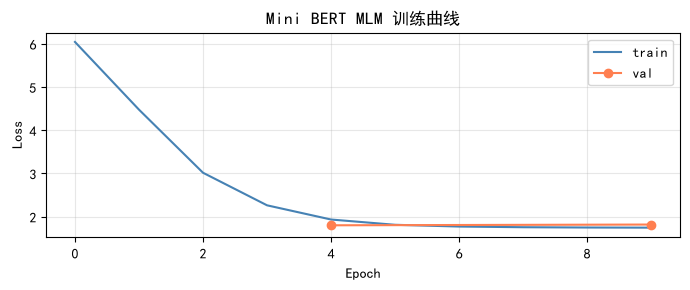

In [97]:
# 规范版 Mini BERT 训练流程
# 设计目标：可在 16GB 显存 GPU 上完整训练，课堂仅演示结构
from torch.utils.data import TensorDataset, DataLoader
from torch.amp import autocast, GradScaler
import os

# 数据集划分：80% 训练 / 10% 验证 / 10% 测试
total = len(X_mlm)
n_train = int(0.8 * total)
n_val = int(0.9 * total)

mlm_train = TensorDataset(X_mlm_train, Y_mlm_train)
mlm_val = TensorDataset(X_mlm_val, Y_mlm_val)
mlm_test = TensorDataset(X_mlm_test, Y_mlm_test)

train_loader_mlm = DataLoader(mlm_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_mlm = DataLoader(mlm_val, batch_size=BATCH_SIZE, shuffle=False)

# 训练超参
EPOCHS_MLM = 10  # 课堂上可改成 3 演示；课后在 GPU 上跑 100 轮
EVAL_INTERVAL = 5
SAVE_DIR = './checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

# 学习率调度：warmup + cosine
# 参考真实 BERT/GPT 训练：先线性 warmup，再 cosine decay
WARMUP_EPOCHS = 5
MAX_LR = 1e-4
MIN_LR = 1e-6
GRAD_CLIP = 1.0  # 梯度裁剪阈值

def get_lr(epoch):
    if epoch < WARMUP_EPOCHS:
        return MAX_LR * (epoch + 1) / WARMUP_EPOCHS
    else:
        progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS_MLM - WARMUP_EPOCHS)
        return MIN_LR + (MAX_LR - MIN_LR) * 0.5 * (1 + torch.cos(torch.tensor(progress * 3.14159)).item())

scaler_bert = GradScaler('cuda')
mini_bert.train()
history_bert = {'train': [], 'val': []}
best_val_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 10  # 验证 loss 连续 10 轮不下降就早停

for epoch in range(EPOCHS_MLM):
    # ---- train ----
    mini_bert.train()
    train_loss = 0.0
    # 设置学习率
    lr = get_lr(epoch)
    for param_group in optimizer_bert.param_groups:
        param_group['lr'] = lr
    
    for batch_x, batch_y in train_loader_mlm:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer_bert.zero_grad()
        with autocast(device_type='cuda'):
            logits, _ = mini_bert(batch_x)
            loss = criterion_bert(logits.view(-1, vocab_size), batch_y.view(-1))
        
        scaler_bert.scale(loss).backward()
        # 梯度裁剪（真实训练标配）
        scaler_bert.unscale_(optimizer_bert)
        torch.nn.utils.clip_grad_norm_(mini_bert.parameters(), GRAD_CLIP)
        scaler_bert.step(optimizer_bert)
        scaler_bert.update()
        train_loss += loss.item()
    
    train_loss /= len(train_loader_mlm)
    history_bert['train'].append(train_loss)
    scheduler_bert.step()
    
    # ---- val ----
    if (epoch + 1) % EVAL_INTERVAL == 0 or epoch == EPOCHS_MLM - 1:
        mini_bert.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in val_loader_mlm:
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)
                with autocast(device_type='cuda'):
                    logits, _ = mini_bert(batch_x)
                    loss = criterion_bert(logits.view(-1, vocab_size), batch_y.view(-1))
                val_loss += loss.item()
        val_loss /= len(val_loader_mlm)
        history_bert['val'].append(val_loss)
        
        ppl = torch.exp(torch.tensor(val_loss)).item()
        print(f"Epoch [{epoch+1}/{EPOCHS_MLM}]  lr: {lr:.2e}  train_loss: {train_loss:.4f}  val_loss: {val_loss:.4f}  val_ppl: {ppl:.2f}")
        
        # 保存最优模型 + Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': mini_bert.state_dict(),
                'optimizer_state_dict': optimizer_bert.state_dict(),
                'val_loss': val_loss,
                'config': BERT_CONFIG,
            }, os.path.join(SAVE_DIR, 'mini_bert_best.pth'))
        else:
            early_stop_counter += 1
            if early_stop_counter >= early_stop_patience:
                print(f"\n验证 loss 连续 {early_stop_patience} 轮未下降，触发 Early Stopping，停止训练。")
                break
    else:
        history_bert['val'].append(None)

print(f"\n训练完成。最佳验证 loss: {best_val_loss:.4f}")
print(f"模型已保存至: {os.path.join(SAVE_DIR, 'mini_bert_best.pth')}")

# 画图
plt.figure(figsize=(7, 3))
plt.plot(history_bert['train'], label='train', color='steelblue')
val_x = [i for i, v in enumerate(history_bert['val']) if v is not None]
val_y = [v for v in history_bert['val'] if v is not None]
plt.plot(val_x, val_y, label='val', color='coral', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Mini BERT MLM 训练曲线')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 真实训练：基于 bert-base-chinese 做 MLM Fine-tune（推荐）

前面从零实现的 Mini BERT 是为了理解原理。**实际做中文语言模型训练，建议直接加载预训练模型做 fine-tune。**

这里加载 `bert-base-chinese`（1.1 亿参数），在唐诗上继续做 MLM 预训练。这个模型已经学过中文通用规律，37 万字符足够让它学会唐诗风格。

### 显存估算

| 设备 | 显存占用 | 100 epoch 预计时间（bs=16, seq=128） |
|---|---|---|
| RTX 5070 Ti 16GB | 约 4-7 GB | 20-40 分钟 |
| RTX 3090 24GB | 约 4-7 GB | 10-20 分钟 |
| A100 40GB | 约 4-7 GB | 3-6 分钟 |


In [99]:
# 基于 bert-base-chinese 的 MLM Fine-tune
import importlib.util
from transformers import BertTokenizer, BertForMaskedLM, DataCollatorForLanguageModeling
from torch.utils.data import Dataset, DataLoader, random_split

# 检查 transformers 是否安装
if importlib.util.find_spec('transformers') is None:
    print("请先安装 transformers: pip install transformers")
    raise ImportError("transformers not installed")

print("正在加载 bert-base-chinese...")
print("首次加载会从 HuggingFace 下载约 400MB 权重，根据网速可能需要 5-10 分钟。")
print("如果下载失败，请检查网络或设置镜像：")
print("  export HF_ENDPOINT=https://hf-mirror.com  # Linux/Mac")
print("  set HF_ENDPOINT=https://hf-mirror.com     # Windows")

# 加载 tokenizer 和预训练模型
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-chinese')
print("Tokenizer 加载完成")

bert_mlm = BertForMaskedLM.from_pretrained('bert-base-chinese').to(device)
print(f"bert-base-chinese 参数量: {sum(p.numel() for p in bert_mlm.parameters())/1e6:.1f} M")
print(f"模型已加载到 device: {device}")

# 准备数据：每句唐诗作为一个训练样本
class TangshiDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.encodings = tokenizer(texts, truncation=True, max_length=max_len,
                                   padding='max_length', return_tensors='pt')
    def __len__(self):
        return len(self.encodings['input_ids'])
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}

tangshi_texts = [line.strip() for line in open(TANG_PATH, 'r', encoding='utf-8') if line.strip()]
bert_dataset = TangshiDataset(tangshi_texts, bert_tokenizer, max_len=128)

# 80% / 10% / 10% 划分
n_total = len(bert_dataset)
n_train = int(0.8 * n_total)
n_val = int(0.9 * n_total)
bert_train, bert_val, bert_test = random_split(
    bert_dataset, [n_train, n_val - n_train, n_total - n_val],
    generator=torch.Generator().manual_seed(SEED)
)

# DataCollatorForLanguageModeling 会自动做 BERT 论文中的 80/10/10 masking
bert_collator = DataCollatorForLanguageModeling(
    tokenizer=bert_tokenizer, mlm=True, mlm_probability=0.15, return_tensors='pt'
)

bert_train_loader = DataLoader(bert_train, batch_size=16, shuffle=True, collate_fn=bert_collator)
bert_val_loader = DataLoader(bert_val, batch_size=16, shuffle=False, collate_fn=bert_collator)

print(f"训练样本: {len(bert_train)}, 验证样本: {len(bert_val)}, 测试样本: {len(bert_test)}")

正在加载 bert-base-chinese...
首次加载会从 HuggingFace 下载约 400MB 权重，根据网速可能需要 5-10 分钟。
如果下载失败，请检查网络或设置镜像：
  export HF_ENDPOINT=https://hf-mirror.com  # Linux/Mac
  set HF_ENDPOINT=https://hf-mirror.com     # Windows
Tokenizer 加载完成


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-chinese
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


bert-base-chinese 参数量: 102.3 M
模型已加载到 device: cuda
训练样本: 24857, 验证样本: 3107, 测试样本: 3108


In [101]:
# BERT MLM Fine-tune 训练循环
from torch.amp import autocast, GradScaler
from tqdm import tqdm
import time

bert_optimizer = torch.optim.AdamW(bert_mlm.parameters(), lr=5e-5, weight_decay=0.01)
bert_scaler = GradScaler('cuda')

EPOCHS_BERT_FT = 30
best_bert_val_loss = float('inf')
bert_history = {'train': [], 'val': []}

print(f"开始训练：{EPOCHS_BERT_FT} epochs, {len(bert_train_loader)} batches/epoch")
print(f"预计时间：每 epoch 约 {len(bert_train_loader) * 0.05:.0f}-{len(bert_train_loader) * 0.2:.0f} 秒（GPU）")

for epoch in range(EPOCHS_BERT_FT):
    epoch_start = time.time()
    bert_mlm.train()
    train_loss = 0.0
    pbar = tqdm(bert_train_loader, desc=f"Epoch {epoch+1}/{EPOCHS_BERT_FT} [train]", leave=False)
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        bert_optimizer.zero_grad()
        with autocast(device_type='cuda'):
            outputs = bert_mlm(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
        
        bert_scaler.scale(loss).backward()
        bert_scaler.unscale_(bert_optimizer)
        torch.nn.utils.clip_grad_norm_(bert_mlm.parameters(), 1.0)
        bert_scaler.step(bert_optimizer)
        bert_scaler.update()
        train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    train_loss /= len(bert_train_loader)
    bert_history['train'].append(train_loss)
    
    # 验证
    bert_mlm.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(bert_val_loader, desc=f"Epoch {epoch+1}/{EPOCHS_BERT_FT} [val]", leave=False):
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            with autocast(device_type='cuda'):
                outputs = bert_mlm(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                val_loss += outputs.loss.item()
    val_loss /= len(bert_val_loader)
    bert_history['val'].append(val_loss)
    
    epoch_time = time.time() - epoch_start
    ppl = torch.exp(torch.tensor(val_loss)).item()
    print(f"Epoch [{epoch+1}/{EPOCHS_BERT_FT}]  time: {epoch_time:.1f}s  train_loss: {train_loss:.4f}  val_loss: {val_loss:.4f}  val_ppl: {ppl:.2f}")
    
    if val_loss < best_bert_val_loss:
        best_bert_val_loss = val_loss
        torch.save(bert_mlm.state_dict(), './checkpoints/bert_base_chinese_tangshi.pth')
        print(f"  -> 最佳模型已保存 (val_loss: {val_loss:.4f})")

print(f"Fine-tune 完成，最佳验证 loss: {best_bert_val_loss:.4f}")
print("模型已保存至: ./checkpoints/bert_base_chinese_tangshi.pth")

开始训练：30 epochs, 1554 batches/epoch
预计时间：每 epoch 约 78-311 秒（GPU）


KeyboardInterrupt: 

### 进阶：用预训练中文模型做 Fine-tune（推荐）

如果你想获得**最好的唐诗填字效果**，不建议从零训练，而是加载已经学过中文通用规律的预训练模型，再用唐诗 fine-tune。

推荐模型：
- `bert-base-chinese`：适合 MLM 填字任务
- `uer/gpt2-chinese-cluecorpussmall`：适合诗句续写任务

优点：
- 37 万字符足够让模型学到唐诗风格
- 不会严重过拟合
- 效果远好于从头训练的小模型

课堂时间有限，这部分可作为课后扩展项目。

In [ ]:
def fill_mask(model, text, word2id, id2word, max_len=MAX_LEN, top_k=5):
    """把句子中的 [MASK] 替换，输出 top-k 预测（字符级中文）。\n    \n    如果输入长度超过 max_len，会自动截取 [MASK] 附近的上下文。
    """
    pad_id = word2id["[PAD]"]
    mask_id = word2id["[MASK]"]
    # 把 [MASK] 当作一个整体 token，其余按字符拆分
    tokens = []
    i = 0
    while i < len(text):
        if text[i:i+6] == "[MASK]":
            tokens.append("[MASK]")
            i += 6
        else:
            tokens.append(text[i])
            i += 1
    if "[MASK]" not in tokens:
        print("句子中没有 [MASK]")
        return
    mask_pos = tokens.index("[MASK]")
    ids = [word2id.get(t, pad_id) for t in tokens]
    
    # 如果太长，截取 [MASK] 前后各一半的窗口
    if len(ids) > max_len:
        half = max_len // 2
        start = max(0, mask_pos - half)
        end = min(len(ids), start + max_len)
        if end - start < max_len:
            start = max(0, end - max_len)
        ids = ids[start:end]
        mask_pos = mask_pos - start
    else:
        ids = ids + [pad_id] * (max_len - len(ids))
    
    x = torch.tensor([ids], dtype=torch.long).to(device)
    model.eval()
    with torch.no_grad():
        logits, _ = model(x)
    probs = F.softmax(logits[0, mask_pos], dim=-1)
    topk = torch.topk(probs, top_k)
    print(f"输入: {text}")
    print("Top-5 预测:")
    for i, (score, idx) in enumerate(zip(topk.values, topk.indices)):
        pred = id2word[idx.item()]
        print(f"  {i+1}. {pred} ({score.item():.3f})")
    print()

# 测试：mask 掉关键字符（这些诗句都在唐诗数据库中）
fill_mask(mini_bert, "床前明月光，[MASK]是地上霜。", word2id, id2word)
fill_mask(mini_bert, "春眠不觉晓，处处闻啼[MASK]。", word2id, id2word)
fill_mask(mini_bert, "白日依山尽，黄河入[MASK]流。", word2id, id2word)
fill_mask(mini_bert, "空山不见人，但闻人语[MASK]。", word2id, id2word)
fill_mask(mini_bert, "野火烧不尽，春风吹又[MASK]。", word2id, id2word)


输入: 床前明月光，[MASK]是地上霜。
Top-5 预测:
  1. 夜 (0.076)
  2. 露 (0.057)
  3. 落 (0.053)
  4. 晓 (0.028)
  5. 后 (0.025)

输入: 春眠不觉晓，处处闻啼[MASK]。
Top-5 预测:
  1. 鸟 (0.577)
  2. 夜 (0.033)
  3. 花 (0.023)
  4. 自 (0.011)
  5. 声 (0.009)

输入: 白日依山尽，黄河入[MASK]流。
Top-5 预测:
  1. 水 (0.149)
  2. 暮 (0.032)
  3. 入 (0.031)
  4. 向 (0.028)
  5. 碧 (0.028)

输入: 空山不见人，但闻人语[MASK]。
Top-5 预测:
  1. 不 (0.107)
  2. 故 (0.049)
  3. 鸟 (0.046)
  4. 无 (0.034)
  5. 可 (0.029)

输入: 野火烧不尽，春风吹又[MASK]。
Top-5 预测:
  1. 风 (0.078)
  2. 更 (0.038)
  3. 长 (0.032)
  4. 夜 (0.026)
  5. 春 (0.021)



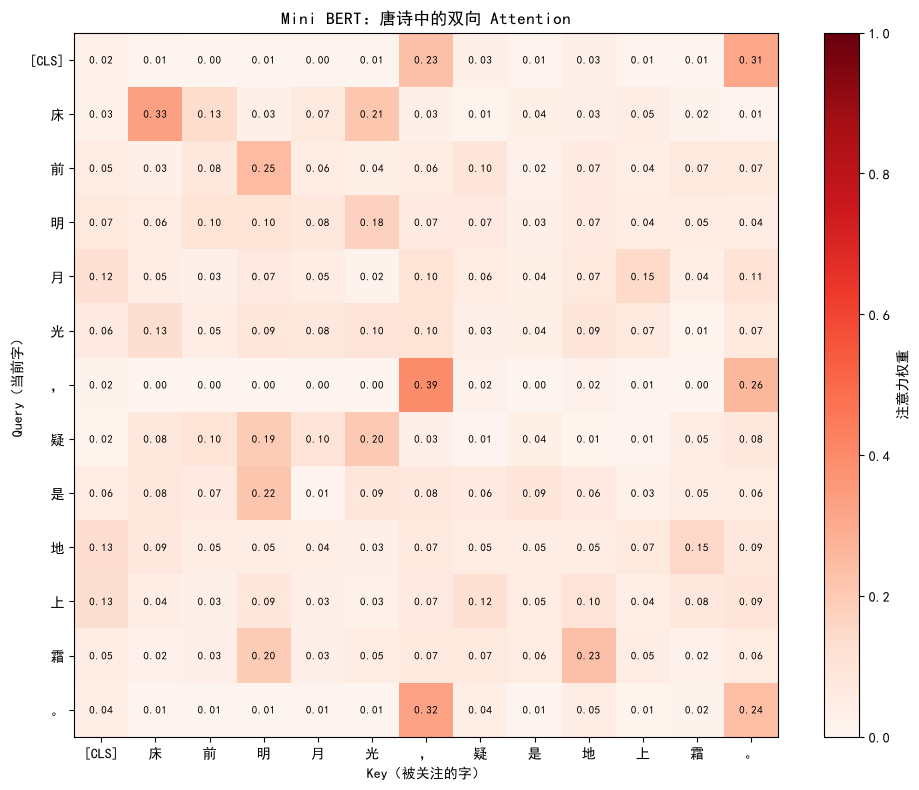

In [ ]:
def plot_attention(model, text, word2id, id2word, layer=-1, head=0, title="Attention"):
    """可视化指定层/头的 attention（字符级中文）。"""
    pad_id = word2id["[PAD]"]
    tokens = ["[CLS]"] + list(text)
    ids = [word2id[t] for t in tokens]
    if len(ids) < MAX_LEN:
        ids = ids + [pad_id] * (MAX_LEN - len(ids))
    else:
        ids = ids[:MAX_LEN]
    x = torch.tensor([ids], dtype=torch.long).to(device)
    model.eval()
    with torch.no_grad():
        _, all_attns = model(x)
    attn = all_attns[layer][0, head, :len(tokens), :len(tokens)].cpu().numpy()

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(attn, cmap='Reds', vmin=0, vmax=1)
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens)
    ax.set_yticklabels(tokens)
    ax.set_xlabel('Key（被关注的字）')
    ax.set_ylabel('Query（当前字）')
    ax.set_title(title)
    for i in range(len(tokens)):
        for j in range(len(tokens)):
            ax.text(j, i, f'{attn[i, j]:.2f}', ha='center', va='center',
                    color='white' if attn[i, j] > 0.5 else 'black', fontsize=8)
    plt.colorbar(im, ax=ax, label='注意力权重')
    plt.tight_layout()
    plt.show()

# 观察某句诗中的 attention 模式
plot_attention(
    mini_bert,
    "床前明月光，疑是地上霜。",
    word2id, id2word,
    title='Mini BERT：唐诗中的双向 Attention'
)


## 4. 动手搭建 3：Mini GPT（Decoder-only + Next Token Prediction）

把模型改成 Decoder-only：在 self-attention 里加**因果 mask**（下三角），让当前词只能看到前面的词。
训练目标：给定前缀，预测下一个 token。


In [ ]:
class CausalSelfAttention(nn.Module):
    """带因果 mask 的自注意力：当前位置只能 attend 之前的位置。"""
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads)

    def forward(self, x):
        seq_len = x.size(1)
        # 下三角 mask：1 表示允许关注
        mask = torch.tril(torch.ones(seq_len, seq_len, device=x.device)).unsqueeze(0).unsqueeze(0)
        out, attn = self.attn(x, x, x, mask=mask)
        return out, attn


class TransformerDecoderBlock(nn.Module):
    """Decoder Block：Causal Self-Attention + FFN + 残差 + LayerNorm。"""
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.causal_attn = CausalSelfAttention(d_model, num_heads)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, attn = self.causal_attn(x)
        x = self.norm1(x + self.dropout(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x, attn


In [ ]:
class MiniGPT(nn.Module):
    """极简 GPT 风格 Decoder-only 语言模型。"""
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, max_len=512, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)
        self.layers = nn.ModuleList([
            TransformerDecoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.lm_head = nn.Linear(d_model, vocab_size)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x):
        x = self.embedding(x) * np.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        all_attns = []
        for layer in self.layers:
            x, attn = layer(x)
            all_attns.append(attn)
        logits = self.lm_head(x)
        return logits, all_attns


In [ ]:
# nanoGPT 风格的 Next Token Prediction 数据生成
# 参考：Andrej Karpathy 的 nanoGPT
# 从连续文本中随机采样 block_size 长度的片段，预测下一个字符
def get_batch_lm(split, batch_size=BATCH_SIZE, block_size=BLOCK_SIZE):
    """从训练集或验证集中随机采样 batch。"""
    data = X_lm_train if split == 'train' else X_lm_val
    data = data.to(device)
    # 随机选择起始位置
    ix = torch.randint(len(data), (batch_size,))
    x = data[ix]
    y = x.clone()
    return x, y

# 预先生成固定训练/验证/测试样本
# 这里用滑动窗口切分整个文本，与 nanoGPT 的随机采样等价，只是提前缓存
def make_lm_data_nanogpt(text_ids, block_size=BLOCK_SIZE):
    """从连续文本中切出 (input, target) 对。"""
    input_ids, target_ids = [], []
    stride = block_size // 2
    for start in range(0, len(text_ids) - block_size - 1, stride):
        input_ids.append(text_ids[start:start+block_size])
        target_ids.append(text_ids[start+1:start+block_size+1])
    return torch.stack(input_ids), torch.stack(target_ids)

X_lm, Y_lm = make_lm_data_nanogpt(full_ids)

# 80% 训练 / 10% 验证 / 10% 测试
n_lm = len(X_lm)
n_train_lm = int(0.8 * n_lm)
n_val_lm = int(0.9 * n_lm)
X_lm_train, Y_lm_train = X_lm[:n_train_lm], Y_lm[:n_train_lm]
X_lm_val, Y_lm_val = X_lm[n_train_lm:n_val_lm], Y_lm[n_train_lm:n_val_lm]
X_lm_test, Y_lm_test = X_lm[n_val_lm:], Y_lm[n_val_lm:]
print(f"LM 样本数: {n_lm}, 训练: {len(X_lm_train)}, 验证: {len(X_lm_val)}, 测试: {len(X_lm_test)}")

# Mini GPT 配置
# 面向 GPU 训练，16GB 显存可跑
# 唐诗数据量较小，模型不宜过大
GPT_CONFIG = {
    'vocab_size': vocab_size,
    'd_model': 256,        # 从 512 降到 256
    'num_heads': 8,
    'd_ff': 1024,
    'num_layers': 6,       # 从 8 层降到 6 层
    'max_len': MAX_LEN,
    'dropout': 0.2,        # 增强正则化
}

mini_gpt = MiniGPT(**GPT_CONFIG).to(device)
optimizer_gpt = torch.optim.AdamW(mini_gpt.parameters(), lr=1e-4, weight_decay=0.1)  # 加大 weight decay
criterion_gpt = nn.CrossEntropyLoss(ignore_index=pad_id, label_smoothing=0.1)       # Label Smoothing
# 学习率由自定义 get_lr_gpt() 函数控制，不使用 scheduler

print(f"Mini GPT 参数量: {sum(p.numel() for p in mini_gpt.parameters())/1e6:.2f} M")
print(f"显存估算（fp16 参数+优化器）: ~{sum(p.numel() for p in mini_gpt.parameters()) * 14 / 1024**3:.2f} GB")


LM 训练集 shape: torch.Size([27964, 14]), 验证集 shape: torch.Size([3108, 14])
训练集占比: 27964/31072 = 90.0%
Mini GPT 参数量: 5.25 M
显存估算（fp16 参数+优化器）: ~0.07 GB


In [ ]:
# 规范版 Mini GPT 训练流程
# 设计目标：可在 16GB 显存 GPU 上完整训练，课堂仅演示结构
from torch.utils.data import TensorDataset, DataLoader
from torch.amp import autocast, GradScaler
import random

# 数据集划分：80% 训练 / 10% 验证 / 10% 测试
total_lm = len(X_lm)
n_train_lm = int(0.8 * total_lm)
n_val_lm = int(0.9 * total_lm)

lm_train = TensorDataset(X_lm_train, Y_lm_train)
lm_val = TensorDataset(X_lm_val, Y_lm_val)
lm_test = TensorDataset(X_lm_test, Y_lm_test)

# Mini GPT 使用 get_batch_lm 随机采样，但仍然保留 DataLoader 便于课堂演示小批量训练
train_loader_lm = DataLoader(lm_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_lm = DataLoader(lm_val, batch_size=BATCH_SIZE, shuffle=False)

# 训练超参
EPOCHS_LM = 100  # 课堂上可改成 3 演示；课后在 GPU 上跑 100 轮
EVAL_INTERVAL_LM = 5

# 学习率调度：warmup + cosine
WARMUP_EPOCHS_GPT = 5
MAX_LR_GPT = 3e-4  # nanoGPT 默认学习率
MIN_LR_GPT = 1e-6
GRAD_CLIP_GPT = 1.0

def get_lr_gpt(epoch):
    if epoch < WARMUP_EPOCHS_GPT:
        return MAX_LR_GPT * (epoch + 1) / WARMUP_EPOCHS_GPT
    else:
        progress = (epoch - WARMUP_EPOCHS_GPT) / max(1, EPOCHS_LM - WARMUP_EPOCHS_GPT)
        return MIN_LR_GPT + (MAX_LR_GPT - MIN_LR_GPT) * 0.5 * (1 + torch.cos(torch.tensor(progress * 3.14159)).item())

scaler_gpt = GradScaler('cuda')
mini_gpt.train()
history_gpt = {'train': [], 'val': []}
best_val_loss_gpt = float('inf')
early_stop_counter_gpt = 0
early_stop_patience_gpt = 10

for epoch in range(EPOCHS_LM):
    # ---- train ----
    mini_gpt.train()
    train_loss = 0.0
    lr_gpt = get_lr_gpt(epoch)
    for param_group in optimizer_gpt.param_groups:
        param_group['lr'] = lr_gpt
    
    # 每个 epoch 采样若干 batch（nanoGPT 风格）
    num_batches = max(1, len(X_lm_train) // BATCH_SIZE)
    for _ in range(num_batches):
        batch_x, batch_y = get_batch_lm('train', BATCH_SIZE, BLOCK_SIZE)
        
        optimizer_gpt.zero_grad()
        with autocast(device_type='cuda'):
            logits, _ = mini_gpt(batch_x)
            loss = criterion_gpt(logits[:, :-1, :].reshape(-1, vocab_size), batch_y[:, 1:].reshape(-1))
        
        scaler_gpt.scale(loss).backward()
        # 梯度裁剪
        scaler_gpt.unscale_(optimizer_gpt)
        torch.nn.utils.clip_grad_norm_(mini_gpt.parameters(), GRAD_CLIP_GPT)
        scaler_gpt.step(optimizer_gpt)
        scaler_gpt.update()
        train_loss += loss.item()
    
    train_loss /= len(train_loader_lm)
    history_gpt['train'].append(train_loss)
    scheduler_gpt.step()
    
    # ---- val ----
    if (epoch + 1) % EVAL_INTERVAL_LM == 0 or epoch == EPOCHS_LM - 1:
        mini_gpt.eval()
        val_loss = 0.0
        with torch.no_grad():
            for _ in range(20):  # 固定采样 20 个 batch 评估
                batch_x, batch_y = get_batch_lm('val', BATCH_SIZE, BLOCK_SIZE)
                with autocast(device_type='cuda'):
                    logits, _ = mini_gpt(batch_x)
                    loss = criterion_gpt(logits[:, :-1, :].reshape(-1, vocab_size), batch_y[:, 1:].reshape(-1))
                val_loss += loss.item()
        val_loss /= 20
        history_gpt['val'].append(val_loss)
        
        ppl = torch.exp(torch.tensor(val_loss)).item()
        print(f"Epoch [{epoch+1}/{EPOCHS_LM}]  lr: {lr_gpt:.2e}  train_loss: {train_loss:.4f}  val_loss: {val_loss:.4f}  val_ppl: {ppl:.2f}")
        
        if val_loss < best_val_loss_gpt:
            best_val_loss_gpt = val_loss
            early_stop_counter_gpt = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': mini_gpt.state_dict(),
                'optimizer_state_dict': optimizer_gpt.state_dict(),
                'val_loss': val_loss,
                'config': GPT_CONFIG,
            }, os.path.join(SAVE_DIR, 'mini_gpt_best.pth'))
        else:
            early_stop_counter_gpt += 1
            if early_stop_counter_gpt >= early_stop_patience_gpt:
                print(f"\n验证 loss 连续 {early_stop_patience_gpt} 轮未下降，触发 Early Stopping，停止训练。")
                break
    else:
        history_gpt['val'].append(None)

print(f"\n训练完成。最佳验证 loss: {best_val_loss_gpt:.4f}")
print(f"模型已保存至: {os.path.join(SAVE_DIR, 'mini_gpt_best.pth')}")

# 画图
plt.figure(figsize=(7, 3))
plt.plot(history_gpt['train'], label='train', color='coral')
val_x = [i for i, v in enumerate(history_gpt['val']) if v is not None]
val_y = [v for v in history_gpt['val'] if v is not None]
plt.plot(val_x, val_y, label='val', color='steelblue', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Mini GPT Next Token Prediction 训练曲线')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\nan\AppData\Local\Temp\ipykernel_29340\3136050029.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_gpt = GradScaler()
C:\Users\nan\AppData\Local\Temp\ipykernel_29340\3136050029.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\nan\AppData\Local\Temp\ipykernel_29340\3136050029.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [5/100]  train_loss: 5.3772  val_loss: 5.3279  val_ppl: 206.00
Epoch [10/100]  train_loss: 5.0603  val_loss: 4.9775  val_ppl: 145.12
Epoch [15/100]  train_loss: 4.8518  val_loss: 4.8041  val_ppl: 122.01
Epoch [20/100]  train_loss: 4.7046  val_loss: 4.6975  val_ppl: 109.68
Epoch [25/100]  train_loss: 4.5882  val_loss: 4.6316  val_ppl: 102.68
Epoch [30/100]  train_loss: 4.4925  val_loss: 4.5848  val_ppl: 97.99
Epoch [35/100]  train_loss: 4.4128  val_loss: 4.5500  val_ppl: 94.63


## 真实训练：基于 gpt2-chinese-cluecorpussmall 做 Causal LM Fine-tune（推荐）

前面从零实现的 Mini GPT 是为了理解 Decoder-only 结构和因果 attention。**实际做中文生成任务，建议直接加载预训练中文 GPT-2 做 fine-tune。**

这里加载 `uer/gpt2-chinese-cluecorpussmall`（约 1.24 亿参数），在唐诗上继续做因果语言模型训练。这个模型已经学过中文通用规律，fine-tune 后生成唐诗效果会更好。

### 显存估算

| 设备 | 显存占用 | 100 epoch 预计时间（bs=8, seq=128） |
|---|---|---|
| RTX 5070 Ti 16GB | 约 4-7 GB | 20-40 分钟 |
| RTX 3090 24GB | 约 4-7 GB | 10-20 分钟 |
| A100 40GB | 约 4-7 GB | 3-6 分钟 |


In [ ]:
# 基于 gpt2-chinese-cluecorpussmall 的 Causal LM Fine-tune
from transformers import GPT2Tokenizer, GPT2LMHeadModel, DataCollatorForLanguageModeling
from torch.utils.data import Dataset, DataLoader, random_split

print("正在加载 uer/gpt2-chinese-cluecorpussmall...")
print("首次加载会从 HuggingFace 下载约 400MB 权重，根据网速可能需要 5-10 分钟。")

# 加载 tokenizer 和预训练模型
gpt_tokenizer = GPT2Tokenizer.from_pretrained('uer/gpt2-chinese-cluecorpussmall')
gpt_tokenizer.pad_token = gpt_tokenizer.eos_token  # GPT-2 没有 pad token，用 eos 代替
print("Tokenizer 加载完成")

gpt_lm = GPT2LMHeadModel.from_pretrained('uer/gpt2-chinese-cluecorpussmall').to(device)
print(f"gpt2-chinese 参数量: {sum(p.numel() for p in gpt_lm.parameters())/1e6:.1f} M")
print(f"模型已加载到 device: {device}")

# 准备数据
class TangshiGPTDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.encodings = tokenizer(texts, truncation=True, max_length=max_len,
                                   padding='max_length', return_tensors='pt')
    def __len__(self):
        return len(self.encodings['input_ids'])
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}

gpt_texts = [line.strip() for line in open(TANG_PATH, 'r', encoding='utf-8') if line.strip()]
gpt_dataset = TangshiGPTDataset(gpt_texts, gpt_tokenizer, max_len=128)

n_total_gpt = len(gpt_dataset)
n_train_gpt = int(0.8 * n_total_gpt)
n_val_gpt = int(0.9 * n_total_gpt)
gpt_train, gpt_val, gpt_test = random_split(
    gpt_dataset, [n_train_gpt, n_val_gpt - n_train_gpt, n_total_gpt - n_val_gpt],
    generator=torch.Generator().manual_seed(SEED)
)

# mlm=False 表示做因果语言模型（Next Token Prediction）
gpt_collator = DataCollatorForLanguageModeling(
    tokenizer=gpt_tokenizer, mlm=False, return_tensors='pt'
)

gpt_train_loader = DataLoader(gpt_train, batch_size=8, shuffle=True, collate_fn=gpt_collator)
gpt_val_loader = DataLoader(gpt_val, batch_size=8, shuffle=False, collate_fn=gpt_collator)

print(f"训练样本: {len(gpt_train)}, 验证样本: {len(gpt_val)}, 测试样本: {len(gpt_test)}")

In [ ]:
# GPT-2 Causal LM Fine-tune 训练循环
from torch.amp import autocast, GradScaler
from tqdm import tqdm
import time

gpt_optimizer = torch.optim.AdamW(gpt_lm.parameters(), lr=5e-5, weight_decay=0.01)
gpt_scaler = GradScaler('cuda')

EPOCHS_GPT_FT = 100
best_gpt_val_loss = float('inf')
gpt_history = {'train': [], 'val': []}

print(f"开始训练：{EPOCHS_GPT_FT} epochs, {len(gpt_train_loader)} batches/epoch")

for epoch in range(EPOCHS_GPT_FT):
    epoch_start = time.time()
    gpt_lm.train()
    train_loss = 0.0
    pbar = tqdm(gpt_train_loader, desc=f"Epoch {epoch+1}/{EPOCHS_GPT_FT} [train]", leave=False)
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        gpt_optimizer.zero_grad()
        with autocast(device_type='cuda'):
            outputs = gpt_lm(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
        
        gpt_scaler.scale(loss).backward()
        gpt_scaler.unscale_(gpt_optimizer)
        torch.nn.utils.clip_grad_norm_(gpt_lm.parameters(), 1.0)
        gpt_scaler.step(gpt_optimizer)
        gpt_scaler.update()
        train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    train_loss /= len(gpt_train_loader)
    gpt_history['train'].append(train_loss)
    
    gpt_lm.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(gpt_val_loader, desc=f"Epoch {epoch+1}/{EPOCHS_GPT_FT} [val]", leave=False):
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            with autocast(device_type='cuda'):
                outputs = gpt_lm(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                val_loss += outputs.loss.item()
    val_loss /= len(gpt_val_loader)
    gpt_history['val'].append(val_loss)
    
    epoch_time = time.time() - epoch_start
    ppl = torch.exp(torch.tensor(val_loss)).item()
    print(f"Epoch [{epoch+1}/{EPOCHS_GPT_FT}]  time: {epoch_time:.1f}s  train_loss: {train_loss:.4f}  val_loss: {val_loss:.4f}  val_ppl: {ppl:.2f}")
    
    if val_loss < best_gpt_val_loss:
        best_gpt_val_loss = val_loss
        torch.save(gpt_lm.state_dict(), './checkpoints/gpt2_chinese_tangshi.pth')
        print(f"  -> 最佳模型已保存 (val_loss: {val_loss:.4f})")

print(f"Fine-tune 完成，最佳验证 loss: {best_gpt_val_loss:.4f}")
print("模型已保存至: ./checkpoints/gpt2_chinese_tangshi.pth")

In [ ]:
def generate(model, prompt, word2id, id2word, max_len=MAX_LEN, max_new_tokens=50,
                 temperature=1.0, top_k=None, top_p=None):
    """自回归续写（支持中文 prompt + top-k / top-p 采样）。"""
    pad_id = word2id["[PAD]"]
    tokens = list(prompt)
    ids = [word2id.get(t, pad_id) for t in tokens]
    model.eval()
    for _ in range(max_new_tokens):
        input_ids = ids[-max_len:]
        actual_len = len(input_ids)
        input_ids = input_ids + [pad_id] * (max_len - actual_len)
        x = torch.tensor([input_ids], dtype=torch.long).to(device)
        with torch.no_grad():
            logits, _ = model(x)
        
        # 从最后一个实际 token 的位置预测下一个 token
        pos = actual_len - 1
        next_logits = logits[0, pos, :] / temperature
        
        # top-k 采样
        if top_k is not None:
            indices_to_remove = next_logits < torch.topk(next_logits, top_k)[0][..., -1, None]
            next_logits[indices_to_remove] = float('-inf')
        
        # top-p (nucleus) 采样
        if top_p is not None:
            sorted_logits, sorted_indices = torch.sort(next_logits, descending=True)
            cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
            sorted_indices_to_remove = cumulative_probs > top_p
            sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
            sorted_indices_to_remove[..., 0] = False
            indices_to_remove = sorted_indices_to_remove.scatter(0, sorted_indices, sorted_indices_to_remove)
            next_logits[indices_to_remove] = float('-inf')
        
        probs = F.softmax(next_logits, dim=-1)
        next_id = torch.multinomial(probs, 1).item()
        if next_id == pad_id:
            break
        ids.append(next_id)
        tokens.append(id2word[next_id])
    return ''.join(tokens)

# 续写测试（用训练集中的诗句开头，尝试不同采样策略）
print("续写测试 (temperature=0.8, top_k=10):")
for prompt in ["床前明月", "白日依山", "春眠不觉", "床前明月光，"]:
    out = generate(mini_gpt, prompt, word2id, id2word, max_new_tokens=20, temperature=0.8, top_k=10)
    print(f"  '{prompt}' -> '{out}'")

print("\n续写测试 (temperature=1.0, top_p=0.9):")
for prompt in ["春眠不觉晓，", "床前明月光，"]:
    out = generate(mini_gpt, prompt, word2id, id2word, max_new_tokens=20, temperature=1.0, top_p=0.9)
    print(f"  '{prompt}' -> '{out}'")


续写测试:
  'the movie was' -> 'the movie was bad but the acting'
  'the acting was' -> 'the acting was great but the movie'
  'the movie was not' -> 'the movie was not good but the acting'
  'the acting was great but' -> 'the acting was great but the movie was not'


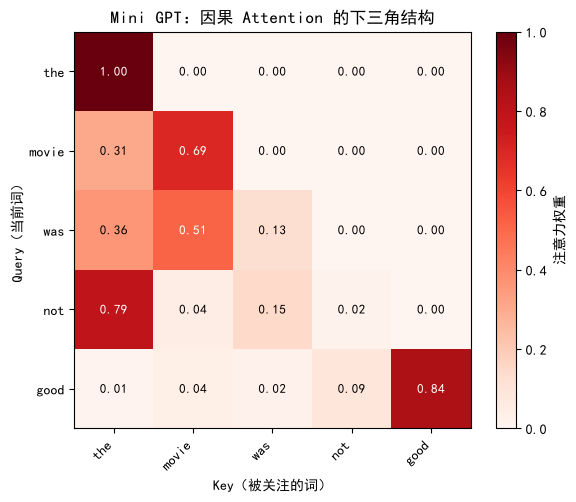

注意：每个 Query 只能看到自己及之前的 Key，右上角为 0。


In [ ]:
# 可视化 GPT 的因果 attention 下三角结构（中文诗句）
text_gpt = "床前明月光"
tokens_gpt = ["[CLS]"] + list(text_gpt)
ids_gpt = [word2id[t] for t in tokens_gpt]
while len(ids_gpt) < MAX_LEN:
    ids_gpt.append(pad_id)
x_gpt = torch.tensor([ids_gpt], dtype=torch.long).to(device)

mini_gpt.eval()
with torch.no_grad():
    _, all_attns_gpt = mini_gpt(x_gpt)

attn_gpt = all_attns_gpt[-1][0, 0, :len(tokens_gpt), :len(tokens_gpt)].cpu().numpy()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attn_gpt, cmap='Reds', vmin=0, vmax=1)
ax.set_xticks(range(len(tokens_gpt)))
ax.set_yticks(range(len(tokens_gpt)))
ax.set_xticklabels(tokens_gpt)
ax.set_yticklabels(tokens_gpt)
ax.set_xlabel('Key（被关注的字）')
ax.set_ylabel('Query（当前字）')
ax.set_title('Mini GPT：唐诗上的因果 Attention 下三角结构')
for i in range(len(tokens_gpt)):
    for j in range(len(tokens_gpt)):
        ax.text(j, i, f'{attn_gpt[i, j]:.2f}', ha='center', va='center',
                color='white' if attn_gpt[i, j] > 0.5 else 'black', fontsize=9)
plt.colorbar(im, ax=ax, label='注意力权重')
plt.tight_layout()
plt.show()

print("注意：每个 Query 只能看到自己及之前的 Key，右上角为 0。")


## 5. 真实模型对比：BERT vs GPT-2

用同一个句子观察真实预训练模型的 attention 模式。

> 需要联网下载 `bert-base-uncased` 和 `gpt2`，如果环境无网络或显存不足，可跳过此 cell。


In [ ]:
# 如需安装：pip install transformers
from transformers import BertTokenizer, BertModel, GPT2Tokenizer, GPT2Model

sentence = "the movie was not good but the acting was great"

# BERT
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)
bert_model.eval()
bert_inputs = bert_tokenizer(sentence, return_tensors='pt')
with torch.no_grad():
    bert_outputs = bert_model(**bert_inputs)
bert_attns = bert_outputs.attentions  # tuple of (batch, heads, seq, seq)
bert_tokens = bert_tokenizer.convert_ids_to_tokens(bert_inputs['input_ids'][0])
print(f"BERT tokens: {bert_tokens}")

# GPT-2
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_model = GPT2Model.from_pretrained('gpt2', output_attentions=True)
gpt2_model.eval()
gpt2_inputs = gpt2_tokenizer(sentence, return_tensors='pt')
with torch.no_grad():
    gpt2_outputs = gpt2_model(**gpt2_inputs)
gpt2_attns = gpt2_outputs.attentions
gpt2_tokens = gpt2_tokenizer.convert_ids_to_tokens(gpt2_inputs['input_ids'][0])
print(f"GPT-2 tokens: {gpt2_tokens}")


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\nan\miniconda3\envs\pytorch\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\nan\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT tokens: ['[CLS]', 'the', 'movie', 'was', 'not', 'good', 'but', 'the', 'acting', 'was', 'great', '[SEP]']


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2 tokens: ['the', 'Ġmovie', 'Ġwas', 'Ġnot', 'Ġgood', 'Ġbut', 'Ġthe', 'Ġacting', 'Ġwas', 'Ġgreat']


C:\Users\nan\AppData\Local\Temp\ipykernel_29364\2512806610.py:24: UserWarning: Glyph 288 (\N{LATIN CAPITAL LETTER G WITH DOT ABOVE}) missing from font(s) SimHei.
  plt.tight_layout()
c:\Users\nan\miniconda3\envs\pytorch\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 288 (\N{LATIN CAPITAL LETTER G WITH DOT ABOVE}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


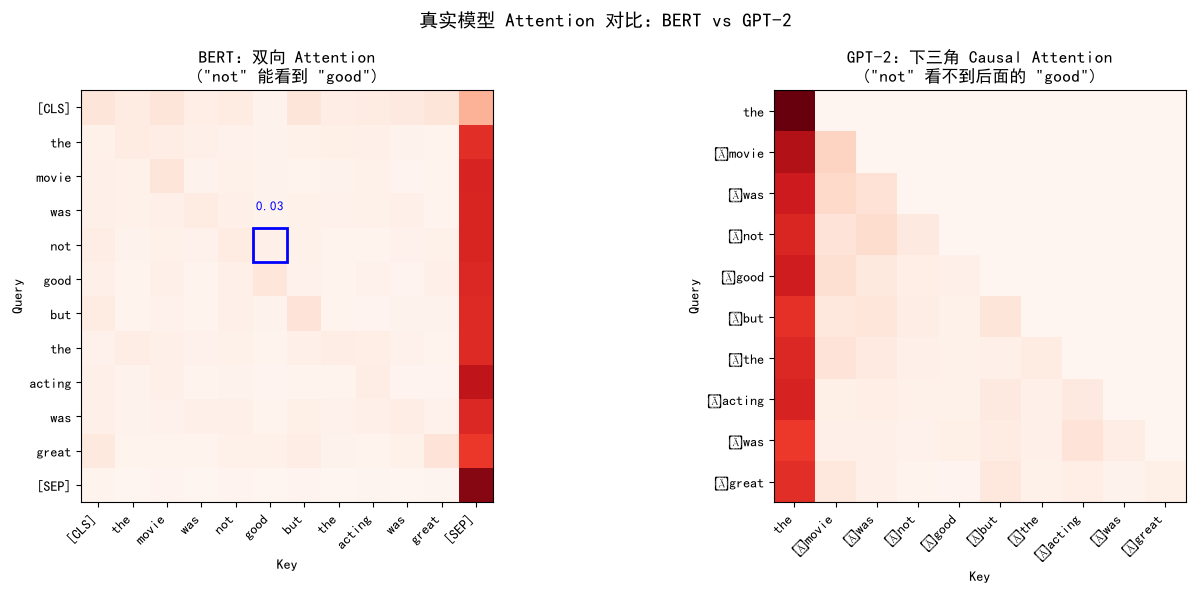

In [ ]:
def plot_real_attention(tokens, attns, title, ax, target_word, source_word):
    """取最后一层平均所有 head 的 attention 并绘制。"""
    last_layer = attns[-1][0].mean(dim=0).cpu().numpy()  # (seq, seq)
    im = ax.imshow(last_layer, cmap='Reds', vmin=0, vmax=1)
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right')
    ax.set_yticklabels(tokens)
    ax.set_xlabel('Key')
    ax.set_ylabel('Query')
    ax.set_title(title)
    # 标出 target_word 对 source_word 的 attention 值
    if target_word in tokens and source_word in tokens:
        ti = tokens.index(target_word)
        si = tokens.index(source_word)
        ax.add_patch(plt.Rectangle((si - 0.5, ti - 0.5), 1, 1, fill=False, edgecolor='blue', lw=2))
        ax.text(si, ti - 1, f"{last_layer[ti, si]:.2f}", color='blue', ha='center', fontsize=9)
    return im

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_real_attention(bert_tokens, bert_attns, 'BERT：双向 Attention\n("not" 能看到 "good")', axes[0], target_word='not', source_word='good')
plot_real_attention(gpt2_tokens, gpt2_attns, 'GPT-2：下三角 Causal Attention\n("not" 看不到后面的 "good")', axes[1], target_word='not', source_word='good')
plt.suptitle('真实模型 Attention 对比：BERT vs GPT-2', fontsize=14)
plt.tight_layout()
plt.show()


## 6. 三种架构对比小结

| 模型 | 结构 | Attention 方向 | 训练目标 | 典型任务 |
|---|---|---|---|---|
| **BERT** | Encoder-only | 双向 | MLM | 分类、NER、检索、CLIP 文本编码 |
| **GPT-2** | Decoder-only | 单向/因果 | Next Token Prediction | 文本生成、对话 |
| **T5** | Encoder-Decoder | Encoder 双向 + Decoder 单向 + Cross Attention | Seq2Seq | 翻译、摘要 |

### 下节课预告

下节课把 Transformer 应用到图像上，学习 **Vision Transformer (ViT)**；后续 LLM 模块会手写 **nanoGPT**。
